## Importación de librerías

In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

BASE_DIR = Path("..").resolve()
DATASET_DIR = BASE_DIR / "dataset"
TRAIN_DIR = DATASET_DIR / "Training"
TEST_DIR = DATASET_DIR / "Testing"

CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

print("¿Existe Training?", TRAIN_DIR.exists())
print("¿Existe Testing? ", TEST_DIR.exists())
print("Carpetas dentro de Training:", [p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])

¿Existe Training? True
¿Existe Testing?  True
Carpetas dentro de Training: ['glioma', 'meningioma', 'notumor', 'pituitary']


## Conteo de imágenes

In [3]:
conteos = []

for split, carpeta in [("Training", TRAIN_DIR), ("Testing", TEST_DIR)]:
    for clase in CLASSES:
        ruta_clase = carpeta / clase
        n = len([f for f in ruta_clase.iterdir() if f.is_file()])
        conteos.append({"split": split, "clase": clase, "cantidad": n})

df = pd.DataFrame(conteos)

tabla = df.pivot(index="clase", columns="split", values="cantidad")
tabla["TOTAL"] = tabla["Training"] + tabla["Testing"]
print(tabla)
print("\nTotal de imágenes:", tabla["TOTAL"].sum())

split       Testing  Training  TOTAL
clase                               
glioma          755      3018   3773
meningioma      546      2183   2729
notumor         487      1945   2432
pituitary       626      2504   3130

Total de imágenes: 12064


## Gráficar 

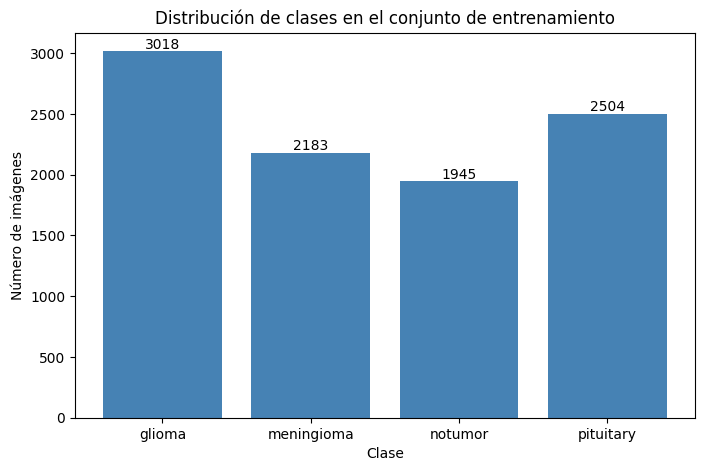

Clase mayoritaria: glioma (3018 imágenes)
Clase minoritaria: notumor (1945 imágenes)
Ratio de desbalance: 1.55x


In [4]:
train_counts = tabla["Training"]

plt.figure(figsize=(8,5))
barras = plt.bar(train_counts.index, train_counts.values, color="steelblue")
plt.title("Distribución de clases en el conjunto de entrenamiento")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 20, str(int(altura)), ha="center")

plt.show()
ratio = train_counts.max() / train_counts.min()
print(f"Clase mayoritaria: {train_counts.idxmax()} ({train_counts.max()} imágenes)")
print(f"Clase minoritaria: {train_counts.idxmin()} ({train_counts.min()} imágenes)")
print(f"Ratio de desbalance: {ratio:.2f}x")

## Propiedades de las imágenes

In [10]:
carpeta_glioma = TRAIN_DIR / "glioma"
primera_imagen = next(f for f in carpeta_glioma.iterdir() if f.is_file())
print("Archivo de ejemplo:", primera_imagen.name)

img = cv2.imread(str(primera_imagen), cv2.IMREAD_UNCHANGED)

print("Tipo de dato:", img.dtype)           
print("Forma (shape):", img.shape)           
print("Valor mínimo de píxel:", img.min())
print("Valor máximo de píxel:", img.max())
print("Número de dimensiones:", img.ndim)

Archivo de ejemplo: gg (325).jpg
Tipo de dato: uint8
Forma (shape): (512, 512, 3)
Valor mínimo de píxel: 0
Valor máximo de píxel: 255
Número de dimensiones: 3


## Escanear muestras de todas las clases

In [11]:
import random

random.seed(42) # semilla fija = resultados reproducibles (mismo muestreo siempre)

N_MUESTRA = 150

formas = []
canales_identicos = 0
total_revisadas = 0

for clase in CLASSES:
    archivos = [f for f in (TRAIN_DIR / clase).iterdir() if f.is_file()]
    muestra = random.sample(archivos, min(N_MUESTRA, len(archivos)))
    for archivo in muestra: 
        im = cv2.imread(str(archivo), cv2.IMREAD_UNCHANGED)
        formas.append(im.shape)
        total_revisadas += 1

        if im.ndim == 3 and im.shape[2] == 3:
            if np.array_equal(im[:, :, 0], im[:, :, 1]) and np.array_equal(im[:, :, 1], im[:, :, 2]): # REVISAR
                canales_identicos += 1

formas_unicas = pd.Series(formas).value_counts()
print("=== Tamaños/formas encontrados (shape: cuántas veces) ===")
print(formas_unicas)
print(f"\nImágenes revisadas: {total_revisadas}")
print(f"Con 3 canales idénticos (gris disfrazado): {canales_identicos}")

=== Tamaños/formas encontrados (shape: cuántas veces) ===
(224, 224, 3)    175
(512, 512, 3)    153
(512, 512)       137
(225, 225, 3)     14
(236, 236, 3)      6
                ... 
(250, 202, 3)      1
(630, 630)         1
(216, 232, 3)      1
(202, 202, 3)      1
(256, 256)         1
Name: count, Length: 83, dtype: int64

Imágenes revisadas: 600
Con 3 canales idénticos (gris disfrazado): 447


## Visualizar imágenes

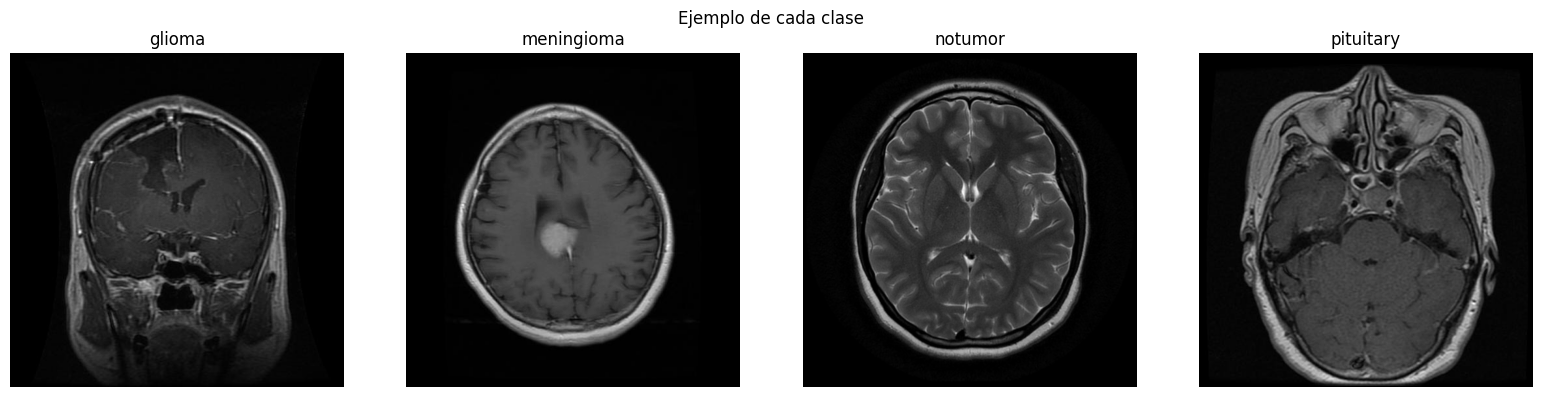

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, clase in zip(axes, CLASSES):
    archivo = next(f for f in (TRAIN_DIR / clase).iterdir() if f.is_file())
    im = cv2.imread(str(archivo), cv2.IMREAD_GRAYSCALE)
    ax.imshow(im, cmap="gray")
    ax.set_title(clase)
    ax.axis("off")

plt.suptitle("Ejemplo de cada clase")
plt.tight_layout() 
plt.show()